In [1]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display
from plotting_utils import (
    get_short_model_name,
    extract_prompt_version,
)
import numpy as np
import matplotlib.ticker as ticker

# Cases where final eligibility outcome tool was not called

It appears that some failures are called because the `eligibility_judgement_outcome()` tool is not called by the agent, so we don't get the structured output we expect. This creates a plot and table of this by configuration. The summary so far is not that surprising - the smaller models forget more often, and as context size grows, it looks like they're more likely to forget.

In [2]:
def build_forgetfulness_df(
    base_dir_str: str = "testOutputs/child_benefit",
) -> pd.DataFrame:
    """
    Scan run directories and build a dataframe showing whether each case
    failed to call the final judgement tool.

    Legacy runs are excluded by checking whether any conversation file in a
    directory contains the eligibility_judgement_outcome tool - if none do
    we probably weren't recording it (rather than all runs failing).
    """
    forgetful_data = []
    base_dir = Path(base_dir_str)

    for run_dir in base_dir.iterdir():
        if not run_dir.is_dir() or run_dir.name == "eval_reports":
            continue

        json_files = list(run_dir.glob("*.conversation.json"))
        if not json_files:
            continue

        # Pre-scan to exclude legacy runs
        is_modern_run = False
        for file_path in json_files:
            try:
                with open(file_path, "r") as f:
                    data = json.load(f)
            except json.JSONDecodeError:
                continue

            tool_activity = data.get("tool_activity", [])
            if any(
                t.get("tool_name") == "eligibility_judgement_outcome"
                for t in tool_activity
            ):
                is_modern_run = True
                break

        if not is_modern_run:
            continue
        
        


        for file_path in json_files:
            try:
                with open(file_path, "r") as f:
                    data = json.load(f)
            except json.JSONDecodeError:
                continue

            meta_block = data.get("meta", {})
            meta_content = meta_block.get("conversation", meta_block)
            run_config = meta_content.get("run_config", {})

            model_string = run_config.get("eligibility_model_string", "unknown")
            if "unknown" in model_string.lower():
                continue
            # Get tokens to see assoc between tokens and forgetting
            usage = data.get("usage", {})
            prompt_tokens = usage.get("total_prompt_tokens")
            
            # Skip if we don't have token counts for this specific run
            if not prompt_tokens:
                continue
            short_model_name = get_short_model_name(model_string)
            prompt_version = extract_prompt_version(
                run_config.get("eligibility_prompt", "v0")
            )
            url_label = (
                "URLs ON"
                if run_config.get("url_tool_call_allowed", True)
                else "URLs OFF"
            )
            config_label = f"{short_model_name} | {prompt_version} | {url_label}"

            tool_activity = data.get("tool_activity", [])
            tool_called = any(
                t.get("tool_name") == "eligibility_judgement_outcome"
                for t in tool_activity
            )

            forgetful_data.append(
                {
                    "run_name": run_dir.name,
                    "config_label": config_label,
                    "failed_to_call": not tool_called,
                    "prompt_tokens" : prompt_tokens
                }
            )

    return pd.DataFrame(forgetful_data)


In [3]:
def plot_forgetfulness_rate(df_forgetful: pd.DataFrame) -> None:
    """
    Plot the percentage of cases where the final judgement tool was not called,
    aggregated by configuration.
    """
    if df_forgetful.empty:
        print("🚨 No valid data found after filtering.")
        return

    summary_plot = (
        df_forgetful.groupby("config_label")["failed_to_call"]
        .agg(["count", "sum"])
        .reset_index()
    )
    summary_plot["failure_rate_pct"] = summary_plot["sum"] / summary_plot["count"] * 100
    summary_plot = summary_plot.sort_values("failure_rate_pct", ascending=False)

    label_order = summary_plot["config_label"].tolist()
    palette = dict(
        zip(label_order, sns.color_palette("Reds_r", n_colors=len(label_order)))
    )

    fig, ax = plt.subplots(figsize=(10, 5))

    sns.barplot(
        data=summary_plot,
        x="failure_rate_pct",
        y="config_label",
        hue="config_label",
        order=label_order,
        hue_order=label_order,
        palette=palette,
        dodge=False,
        legend=False,
        ax=ax,
    )

    ax.set_title(
        "Final judgement tool call failure rate by configuration\n"
        "(% of cases where final judgement tool was not called)",
        fontsize=14,
        pad=15,
    )
    ax.set_xlabel("Failure Rate (%)", fontsize=12)
    ax.set_ylabel("Model Configuration", fontsize=12)

    for patch in ax.patches:
        width = patch.get_width()
        if width > 0:
            ax.text(
                width + 1,
                patch.get_y() + patch.get_height() / 2,
                f"{width:.1f}%",
                ha="left",
                va="center",
                fontweight="bold",
            )

    upper = max(summary_plot["failure_rate_pct"].max() + 10, 10)
    ax.set_xlim(0, upper)
    ax.grid(axis="x", linestyle="--", alpha=0.7)

    plt.tight_layout()
    plt.show()


def make_forgetfulness_summary_table(df_forgetful: pd.DataFrame):
    """
    Create a styled per-run summary table showing tool-call failure rates.
    """
    summary_table = (
        df_forgetful.groupby(["config_label", "run_name"])["failed_to_call"]
        .agg(["count", "sum"])
        .reset_index()
    )
    summary_table["failure_rate_pct"] = (
        summary_table["sum"] / summary_table["count"] * 100
    )

    summary_table = summary_table.rename(
        columns={
            "config_label": "Model Configuration",
            "run_name": "Directory (Run Timestamp)",
            "count": "Total Cases",
            "sum": "Cases Missing Tool",
            "failure_rate_pct": "Failure Rate (%)",
        }
    ).sort_values(by=["Model Configuration", "Directory (Run Timestamp)"])

    def highlight_failures(val):
        if isinstance(val, (int, float)) and val > 0:
            return "background-color: #ffcccc"
        return ""

    return summary_table.style.format({"Failure Rate (%)": "{:.1f}%"}).map(
        highlight_failures,
        subset=["Cases Missing Tool", "Failure Rate (%)"],
    )

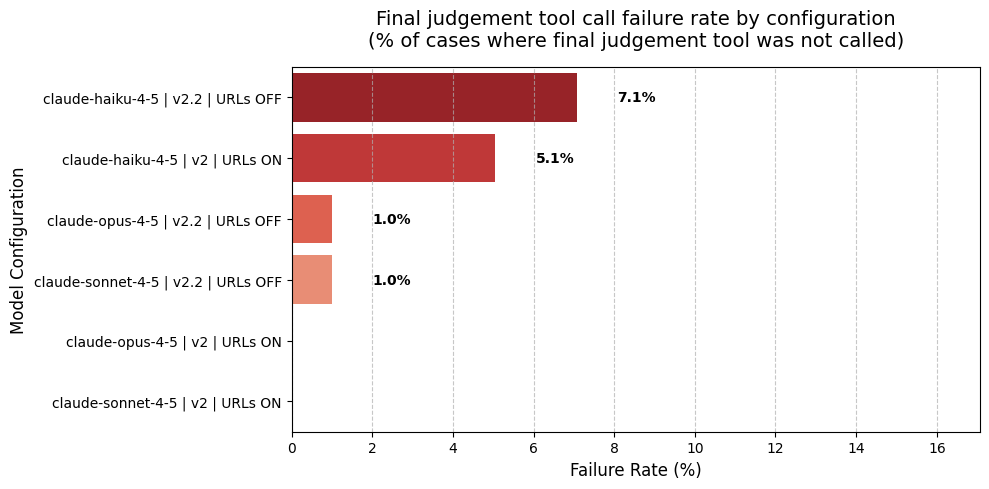


=== Tool Call Failure Rate Breakdown (Per Run) ===


,Model Configuration,Directory (Run Timestamp),Total Cases,Cases Missing Tool,Failure Rate (%)
0,claude-haiku-4-5 | v2 | URLs ON,2026-03-05T21:02:49.150163__Model=claude-haiku-4-5__Commit=de4cbdf,99,5,5.1%
1,claude-haiku-4-5 | v2.2 | URLs OFF,2026-03-06T16:14:17.738276__Model=claude-haiku-4-5__Commit=de4cbdf,99,7,7.1%
2,claude-opus-4-5 | v2 | URLs ON,2026-03-05T18:24:18.571514__Model=claude-opus-4-5__Commit=63c7add,99,0,0.0%
3,claude-opus-4-5 | v2.2 | URLs OFF,2026-03-06T18:34:11.908109__Model=claude-opus-4-5__Commit=de4cbdf,99,1,1.0%
4,claude-sonnet-4-5 | v2 | URLs ON,2026-03-05T19:48:11.152784__Model=claude-sonnet-4-5__Commit=63c7add,99,0,0.0%
5,claude-sonnet-4-5 | v2.2 | URLs OFF,2026-03-06T17:08:17.760944__Model=claude-sonnet-4-5__Commit=de4cbdf,99,1,1.0%


In [4]:
df_forgetful = build_forgetfulness_df("testOutputs/child_benefit")
plot_forgetfulness_rate(df_forgetful)

print("\n=== Tool Call Failure Rate Breakdown (Per Run) ===")
display(make_forgetfulness_summary_table(df_forgetful))

# Tool call fails by model configuration and tokens

Generating plots for 6 configurations...



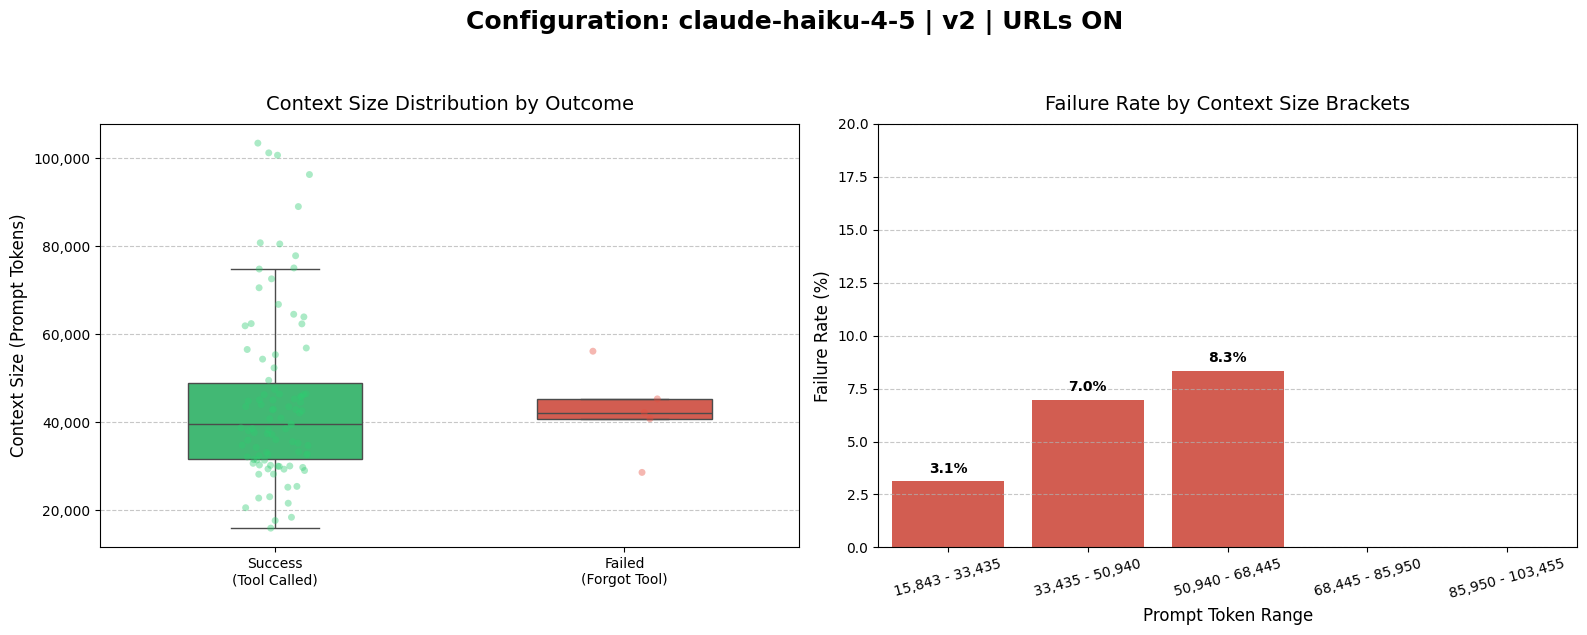

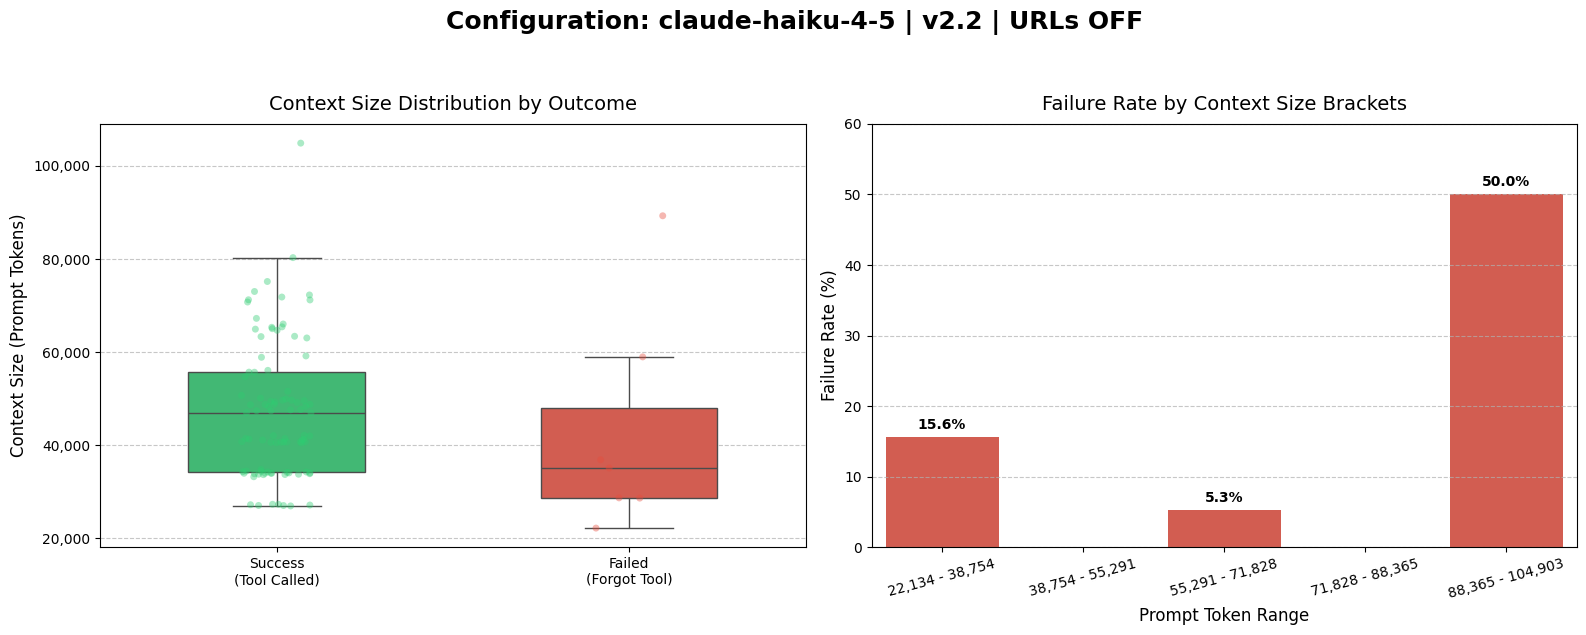

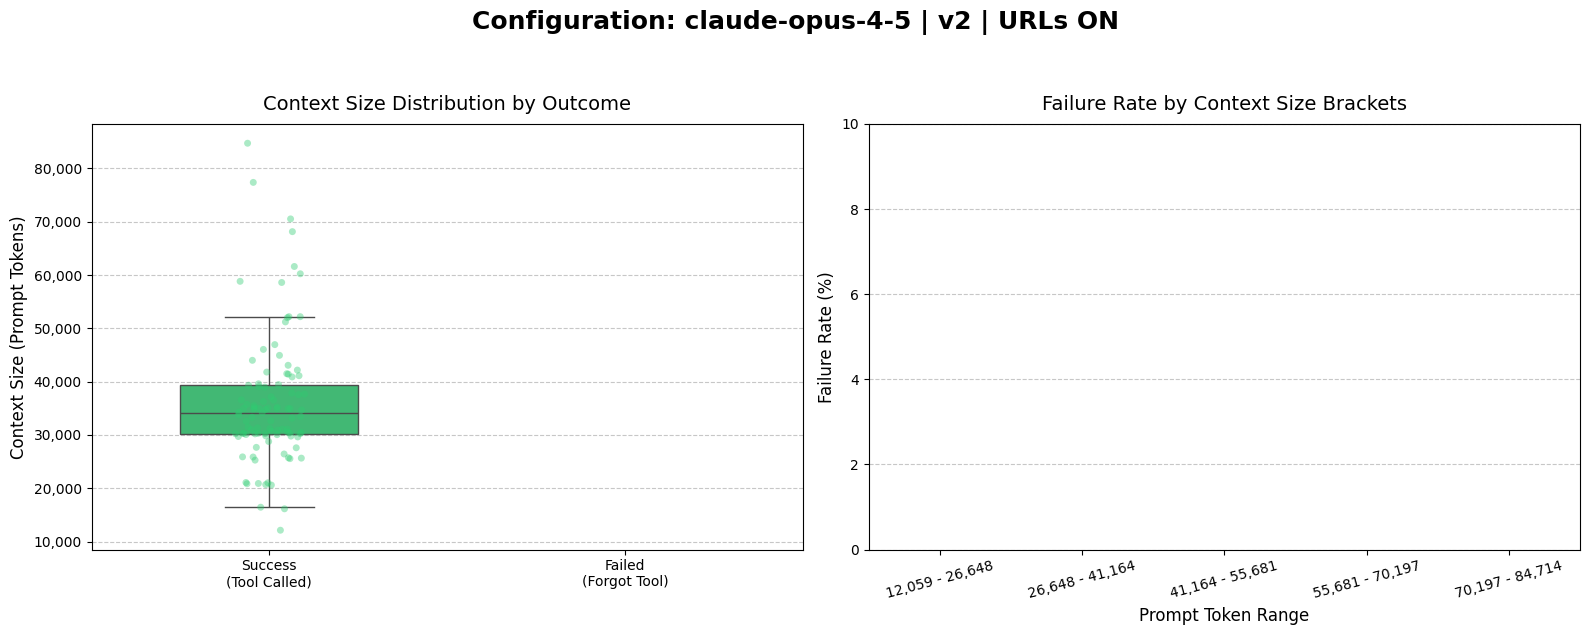

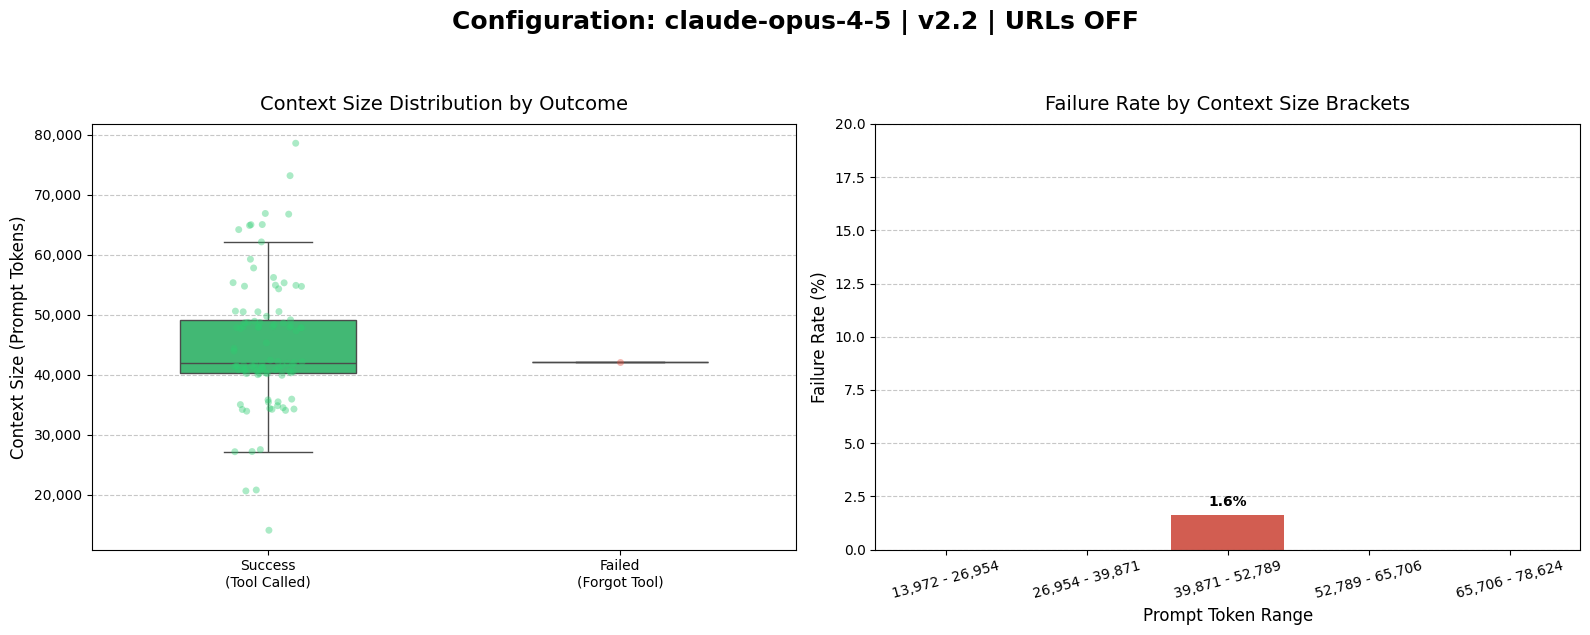

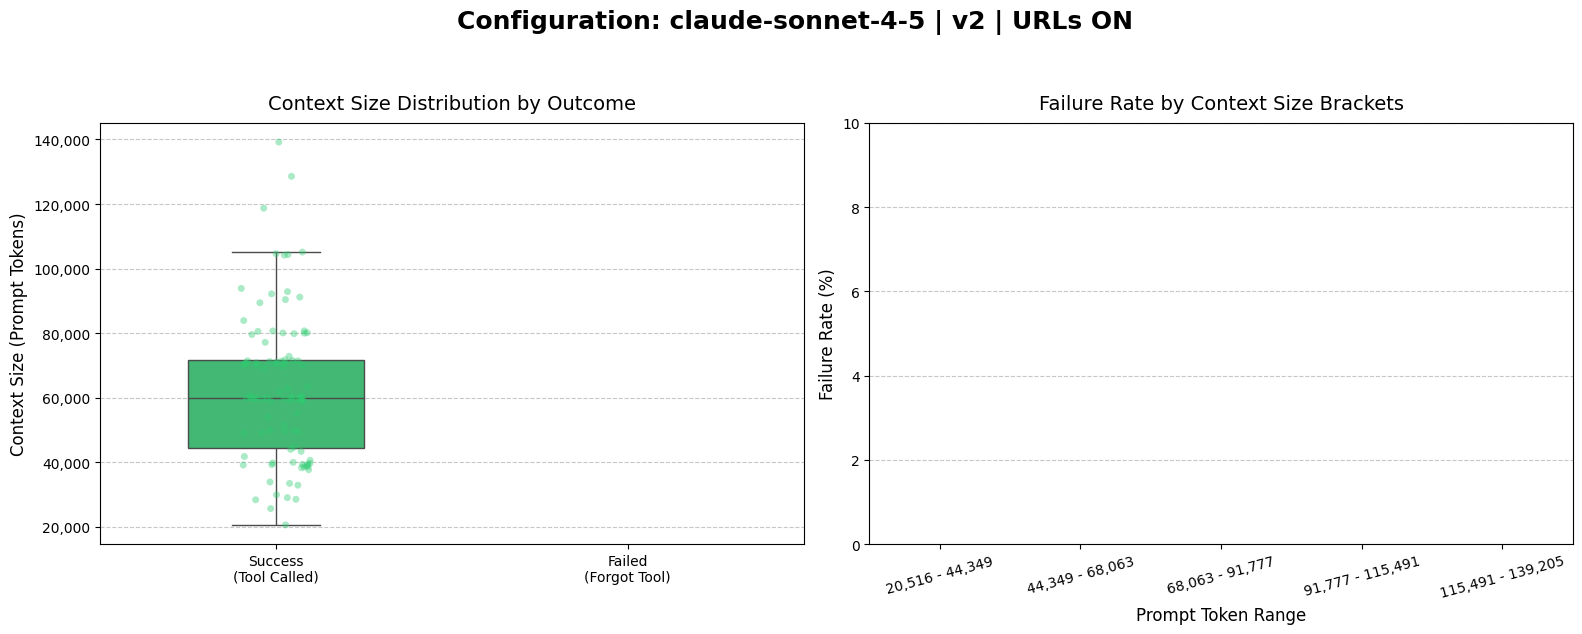

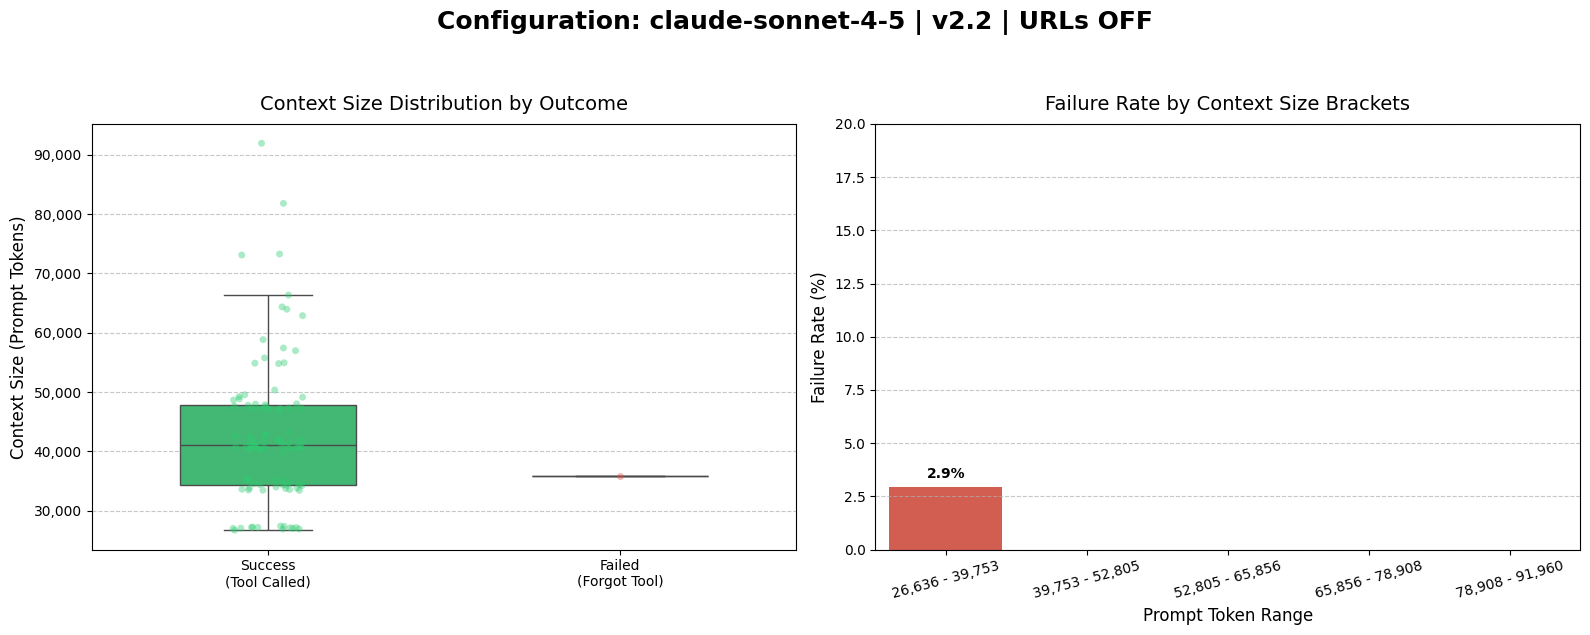

In [5]:
unique_configs = df_forgetful['config_label'].unique()

print(f"Generating plots for {len(unique_configs)} configurations...\n")

for config in sorted(unique_configs):
    # Isolate the data for just this configuration
    df_sub = df_forgetful[df_forgetful['config_label'] == config].copy()
    
    if df_sub.empty:
        continue
        
    # Set up the figure with a dynamic super-title
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f"Configuration: {config}", fontsize=18, fontweight='bold', y=1.05)

    # --- Plot 1: Boxplot of Context Size by Outcome ---
    df_sub['Outcome'] = df_sub['failed_to_call'].astype(int).map({
        0: 'Success\n(Tool Called)', 
        1: 'Failed\n(Forgot Tool)'
    })
    
    df_plot = df_sub.dropna(subset=['Outcome', 'prompt_tokens'])

    outcome_colors = {
        'Success\n(Tool Called)': '#2ecc71', 
        'Failed\n(Forgot Tool)': '#e74c3c'
    }
    
    # Enforce ordering so the colors and positions stay consistent even if a category is missing
    outcome_order = ['Success\n(Tool Called)', 'Failed\n(Forgot Tool)']

    sns.boxplot(
        data=df_plot, x='Outcome', y='prompt_tokens', 
        hue='Outcome', palette=outcome_colors, width=0.5, 
        showfliers=False, legend=False, order=outcome_order, ax=axes[0]
    )
    sns.stripplot(
        data=df_plot, x='Outcome', y='prompt_tokens', 
        hue='Outcome', palette=outcome_colors, alpha=0.4, 
        jitter=True, size=5, legend=False, order=outcome_order, ax=axes[0]
    )

    axes[0].set_title('Context Size Distribution by Outcome', fontsize=14, pad=10)
    axes[0].set_ylabel('Context Size (Prompt Tokens)', fontsize=12)
    axes[0].set_xlabel('')
    axes[0].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
    axes[0].grid(axis='y', linestyle='--', alpha=0.7)

    # --- Plot 2: Failure Rate by Context Size Brackets ---
    # If the tokens are identical across all runs (e.g. URLs OFF), use 1 bin to avoid math errors
    if df_sub['prompt_tokens'].nunique() > 4:
        df_sub['Token_Bucket'] = pd.cut(df_sub['prompt_tokens'], bins=5)
    else:
        df_sub['Token_Bucket'] = pd.cut(df_sub['prompt_tokens'], bins=1)

    bucket_summary = df_sub.groupby('Token_Bucket', observed=False)['failed_to_call'].mean() * 100
    bucket_summary = bucket_summary.reset_index()

    def format_interval(interval):
        if pd.isna(interval): return "Unknown"
        return f"{int(interval.left):,} - {int(interval.right):,}"
    
    bucket_summary['Bucket_Label'] = bucket_summary['Token_Bucket'].apply(format_interval)

    sns.barplot(
        data=bucket_summary, x='Bucket_Label', y='failed_to_call', 
        color='#e74c3c', ax=axes[1]
    )

    axes[1].set_title('Failure Rate by Context Size Brackets', fontsize=14, pad=10)
    axes[1].set_ylabel('Failure Rate (%)', fontsize=12)
    axes[1].set_xlabel('Prompt Token Range', fontsize=12)
    axes[1].grid(axis='y', linestyle='--', alpha=0.7)
    
    # Dynamically scale the y-axis so 0% failure plots don't look broken
    max_fail = bucket_summary['failed_to_call'].max()
    if pd.isna(max_fail) or max_fail == 0:
        axes[1].set_ylim(0, 10)
    else:
        axes[1].set_ylim(0, max(max_fail + 10, 20))

    # Add percentage labels on top of the bars
    for p in axes[1].patches:
        height = p.get_height()
        if height > 0:
            # Place text slightly above the bar based on chart limits
            offset = axes[1].get_ylim()[1] * 0.02
            axes[1].text(
                p.get_x() + p.get_width()/2., height + offset, 
                f'{height:.1f}%', ha='center', fontweight='bold'
            )

    axes[1].tick_params(axis='x', rotation=15)

    plt.tight_layout()
    plt.show()